In [45]:
!pip install requests pandas matplotlib seaborn -q
print("Библиотеки установлены")


Библиотеки установлены


In [46]:
from google.colab import files
import os

print("Загрузите файл логов Suricata (.json)")
uploaded = files.upload()

# Автоопределение JSON файла
log_files = [f for f in uploaded.keys() if f.endswith('.json')]
if log_files:
    LOG_FILE = log_files[0]
    print(f"Автовыбор: {LOG_FILE}")

    # Сохраняем
    with open(LOG_FILE, 'wb') as f:
        f.write(uploaded[LOG_FILE])
else:
    print("Нет .json! ")


Загрузите файл логов Suricata (.json)


Saving alerts-only.json to alerts-only (3).json
Автовыбор: alerts-only (3).json


In [47]:
# API-КЛЮЧ VIRUSTOTAL
VT_API_KEY = "216e0b465a56fd83351f0c1b5cae17a8e2fabebf4c587ce49c37fe1d9e42cb36"
print(f"API ключ: {'Установлен' if VT_API_KEY else 'НЕ УСТАНОВЛЕН'}")

API ключ: Установлен


 Анализ eve (6).json 
Загружено: 285 строк
 Найденные IP колонки:
{'src_ip': 'src_ip', 'dst_ip': 'dest_ip'}
 Используем src_ip: 'src_ip'

 ТОП IP:
               ip  alert_count
0     8.42.77.171           64
1     138.68.3.71           17
2    92.63.194.33            6
3    185.53.91.55            6
4   37.49.231.178            6
5  194.28.115.243            4
6    185.176.27.6            3
7  194.28.115.245            3
8  43.227.231.129            3
9  185.244.25.145            3


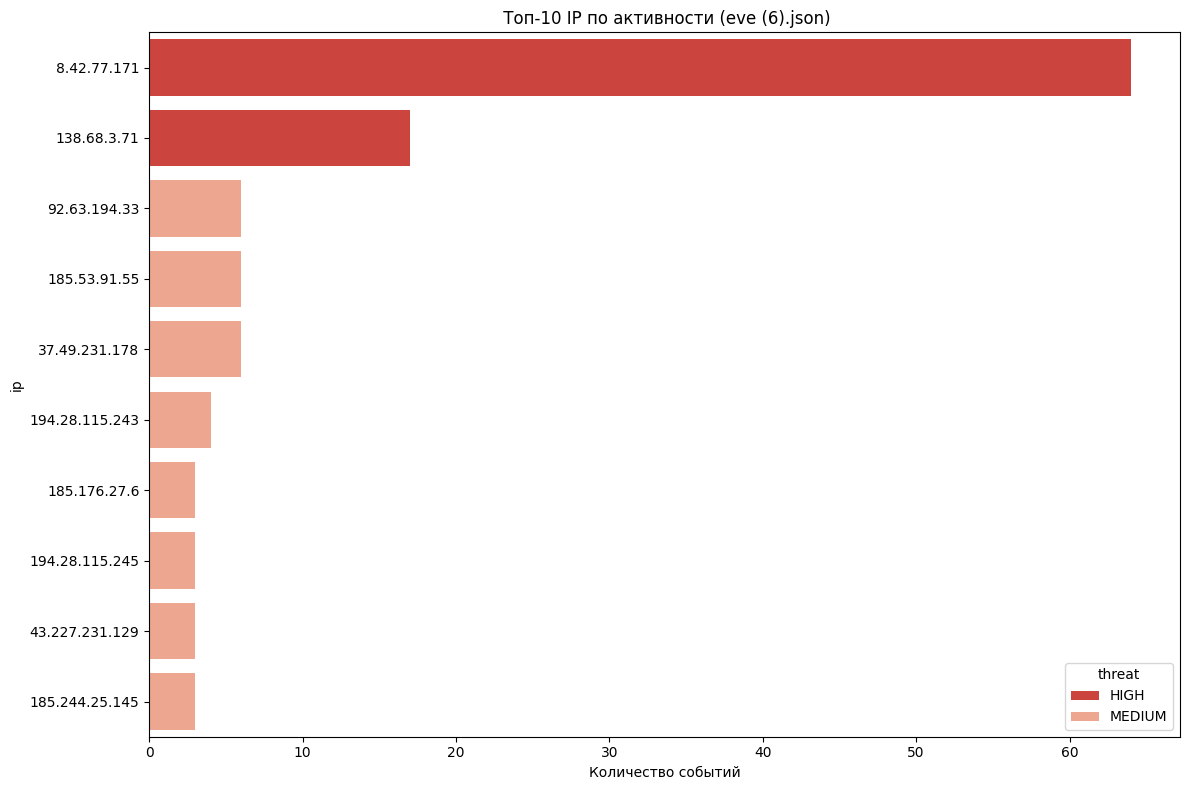


 ФАЙЛЫ ГОТОВЫ:
    threats_20260311_1748.csv
    threats_20260311_1748.json
    threat_chart.png


In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from datetime import datetime
import os

# Файл уже определён
json_files = [f for f in os.listdir('.') if f.endswith('.json')]
LOG_FILE = json_files[0]
print(f" Анализ {LOG_FILE} ")
print("=" * 70)

# Читаем заново с правильной логикой
df = pd.read_json(LOG_FILE, lines=True)
print(f"Загружено: {len(df)} строк")

# ИЩЕМ IP точно (проверяем все варианты)
ip_mapping = {}
for col in df.columns:
    if 'ip' in col.lower():
        if 'src' in col.lower() or 'source' in col.lower():
            ip_mapping['src_ip'] = col
        elif 'dst' in col.lower() or 'dest' in col.lower():
            ip_mapping['dst_ip'] = col

print(" Найденные IP колонки:")
print(ip_mapping)

# Если не нашлось — берём первые колонки с 'ip'
if not ip_mapping:
    ip_cols = [col for col in df.columns if 'ip' in col.lower()]
    if ip_cols:
        ip_mapping['src_ip'] = ip_cols[0]  # первый найденный

src_ip_col = ip_mapping.get('src_ip')
if src_ip_col:
    print(f" Используем src_ip: '{src_ip_col}'")

    # Анализ событий по IP
    ip_counts = df[src_ip_col].value_counts().head(50)

    analysis_df = pd.DataFrame({
        'ip': ip_counts.index,
        'alert_count': ip_counts.values
    })

    print("\n ТОП IP:")
    print(analysis_df.head(10))

    # Простая классификация угроз (без VT пока)
    analysis_df['threat'] = analysis_df['alert_count'].apply(
        lambda x: 'HIGH' if x >= 10 else 'MEDIUM' if x >= 3 else 'LOW'
    )

    # =========================
    # ГРАФИК
    # =========================
    plt.figure(figsize=(12, 8))
    top10 = analysis_df.nlargest(10, 'alert_count')
    sns.barplot(data=top10, x='alert_count', y='ip', hue='threat', palette='Reds_r')
    plt.title(f' Топ-10 IP по активности ({LOG_FILE})')
    plt.xlabel('Количество событий')
    plt.tight_layout()
    plt.savefig('threat_chart.png', dpi=150, bbox_inches='tight')
    plt.show()

    # =========================
    # ОТЧЁТЫ
    # =========================
    timestamp = datetime.now().strftime("%Y%m%d_%H%M")
    analysis_df.to_csv(f'threats_{timestamp}.csv', index=False)
    analysis_df.to_json(f'threats_{timestamp}.json', orient='records', indent=2)

    print(f"\n ФАЙЛЫ ГОТОВЫ:")
    print(f"    threats_{timestamp}.csv")
    print(f"    threats_{timestamp}.json")
    print(f"    threat_chart.png")

